# Notebook 07 — Model Evaluation & Comparison

**Project**: Amharic Sentiment Analysis Platform  
**Author**: Eyob Nebyou  
**Goal**: Full evaluation of Afro-XLM-R vs TF-IDF baseline — results table for the paper.

---

## What We're Doing

1. Load the best fine-tuned model (seed 42 — highest F1)
2. Run full evaluation on the test set
3. Compare per-class F1 against the baseline
4. Build confusion matrices for both models
5. Generate the final results table for the paper

---

In [12]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix
)

pd.set_option('display.max_colwidth', 200)
os.makedirs('../reports', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Test Data

In [13]:
# ── Load clean test set ────────────────────────────────────────
test_df = pd.read_parquet('../data/processed/test_clean.parquet')
print(f'Test set: {test_df.shape}')
print(f'\nClass distribution:')
print(test_df['sentiment'].value_counts())
print(f'\nDefault rate check — negative dominates: {test_df["sentiment"].value_counts(normalize=True)["negative"]:.1%}')

Test set: (1999, 4)

Class distribution:
sentiment
negative    1337
positive     438
neutral      224
Name: count, dtype: int64

Default rate check — negative dominates: 66.9%


## 2. Baseline Model Evaluation

In [14]:
# ── Load baseline and get predictions ─────────────────────────
baseline_model = joblib.load('../models/baseline_model.joblib')
tfidf = joblib.load('../models/tfidf_vectorizer.joblib')

X_test_tfidf = tfidf.transform(test_df['clean_tweet'])
y_true = test_df['sentiment']
baseline_pred = baseline_model.predict(X_test_tfidf)

baseline_macro_f1 = f1_score(y_true, baseline_pred, average='macro')
baseline_acc = accuracy_score(y_true, baseline_pred)

# Per-class F1
baseline_per_class = f1_score(y_true, baseline_pred, 
                               average=None, 
                               labels=['negative', 'neutral', 'positive'])

print(f'Baseline (TF-IDF + Logistic Regression):')
print(f'  Macro F1:  {baseline_macro_f1:.4f}')
print(f'  Accuracy:  {baseline_acc:.4f}')
print(f'  Negative F1: {baseline_per_class[0]:.4f}')
print(f'  Neutral F1:  {baseline_per_class[1]:.4f}')
print(f'  Positive F1: {baseline_per_class[2]:.4f}')

Baseline (TF-IDF + Logistic Regression):
  Macro F1:  0.4640
  Accuracy:  0.4997
  Negative F1: 0.6107
  Neutral F1:  0.2550
  Positive F1: 0.5262


## 3. Transformer Model Evaluation

We use seed 42 (best performing) for detailed evaluation.  
The paper reports mean ± std across all 3 seeds.

In [15]:
# ── Load transformer model ────────────────────────────────────
# The trained best model is stored outside the Git repository
# because model.safetensors is >100 MB.

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader
from datasets import Dataset

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {0: 'negative', 1: 'neutral', 2: 'positive'}

MODEL_PATH = os.path.expanduser(
    '~/amharic-models/best_transformer'
)

MAX_LENGTH = 72

if not os.path.isdir(MODEL_PATH):
    raise FileNotFoundError(
        f"Best transformer model not found at:\n{MODEL_PATH}\n\n"
        "Make sure best_transformer.zip has been extracted to:\n"
        "~/amharic-models/best_transformer/"
    )

print(f"Model found at: {MODEL_PATH}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

transformer_model.to(device)
transformer_model.eval()

print("Tokenizer loaded.")
print("Transformer model loaded.")
print(f"Device: {device}")

Model found at: /Users/eyobnebyou/amharic-models/best_transformer


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tokenizer loaded.
Transformer model loaded.
Device: cpu


In [26]:

# ── Generate transformer predictions (seed 42) ────────────────
# Run the best fine-tuned Afro-XLM-R model on the same test set
# used for the TF-IDF baseline.

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Create Hugging Face dataset from the test data
transformer_test = Dataset.from_pandas(
    test_df[['clean_tweet', 'sentiment']],
    preserve_index=False
)

def tokenize_batch(batch):
    return tokenizer(
        batch['clean_tweet'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )

transformer_test = transformer_test.map(
    tokenize_batch,
    batched=True,
    desc='Tokenizing test set'
)

# Keep only tensors required by the model
transformer_test.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask']
)

test_loader = DataLoader(
    transformer_test,
    batch_size=16,
    shuffle=False
)

# Generate predictions
transformer_predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Generating transformer predictions'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = transformer_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=-1)
        transformer_predictions.extend(
            predictions.cpu().numpy()
        )

# Convert numeric predictions back to sentiment labels
transformer_pred = np.array([
    ID2LABEL[int(pred)]
    for pred in transformer_predictions
])

print(f'Transformer predictions generated: {len(transformer_pred)}')
print(f'Test examples: {len(y_true)}')
print(f'Predictions match test set: {len(transformer_pred) == len(y_true)}')



Tokenizing test set:   0%|          | 0/1999 [00:00<?, ? examples/s]

Generating transformer predictions:   0%|          | 0/125 [00:00<?, ?it/s]

Transformer predictions generated: 1999
Test examples: 1999
Predictions match test set: True


In [16]:
# ── Multi-seed results from training ──────────────────────────
# These come directly from our Day 7 training output

seeds       = [42, 123, 456]
seed_f1s    = [0.5620, 0.5553, 0.5455]
mean_f1     = np.mean(seed_f1s)
std_f1      = np.std(seed_f1s)

print('Transformer (Afro-XLM-R base) — Multi-seed Results:')
for seed, f1 in zip(seeds, seed_f1s):
    print(f'  Seed {seed}: Macro F1 = {f1:.4f}')
print(f'\n  Mean F1: {mean_f1:.4f}')
print(f'  Std F1:  {std_f1:.4f}')
print(f'  Paper result: {mean_f1:.4f} ± {std_f1:.4f}')

Transformer (Afro-XLM-R base) — Multi-seed Results:
  Seed 42: Macro F1 = 0.5620
  Seed 123: Macro F1 = 0.5553
  Seed 456: Macro F1 = 0.5455

  Mean F1: 0.5543
  Std F1:  0.0068
  Paper result: 0.5543 ± 0.0068


## 4. Results Comparison Table

In [27]:

# ── Final comparison table ─────────────────────────────────────
# Compare the baseline with the best transformer model (seed 42).
# Multi-seed Macro F1 is reported as mean ± std for the paper.

# Detailed transformer metrics from seed 42
transformer_macro_f1 = f1_score(
    y_true,
    transformer_pred,
    average='macro'
)

transformer_acc = accuracy_score(
    y_true,
    transformer_pred
)

transformer_per_class = f1_score(
    y_true,
    transformer_pred,
    average=None,
    labels=['negative', 'neutral', 'positive']
)

# Improvement over baseline using the multi-seed mean
improvement = mean_f1 - baseline_macro_f1

results_table = pd.DataFrame([
    {
        'System': 'TF-IDF + Logistic Regression',
        'Type': 'Baseline',
        'Macro F1': f'{baseline_macro_f1:.4f}',
        'Accuracy': f'{baseline_acc:.4f}',
        'Neg F1': f'{baseline_per_class[0]:.4f}',
        'Neu F1': f'{baseline_per_class[1]:.4f}',
        'Pos F1': f'{baseline_per_class[2]:.4f}'
    },
    {
        'System': 'Afro-XLM-R base (fine-tuned)',
        'Type': 'Ours',
        'Macro F1': f'{mean_f1:.4f} ± {std_f1:.4f}',
        'Accuracy': f'{transformer_acc:.4f}',
        'Neg F1': f'{transformer_per_class[0]:.4f}',
        'Neu F1': f'{transformer_per_class[1]:.4f}',
        'Pos F1': f'{transformer_per_class[2]:.4f}'
    }
])

print('=' * 90)
print('RESULTS TABLE (for paper)')
print('=' * 90)
print(results_table.to_string(index=False))

print(
    f'\nTransformer seed 42 Macro F1: '
    f'{transformer_macro_f1:.4f}'
)

print(
    f'Multi-seed Macro F1: '
    f'{mean_f1:.4f} ± {std_f1:.4f}'
)

print(
    f'Improvement over baseline: '
    f'+{improvement:.4f} ({improvement * 100:.2f} points)'
)



RESULTS TABLE (for paper)
                      System     Type        Macro F1 Accuracy Neg F1 Neu F1 Pos F1
TF-IDF + Logistic Regression Baseline          0.4640   0.4997 0.6107 0.2550 0.5262
Afro-XLM-R base (fine-tuned)     Ours 0.5543 ± 0.0068   0.6123 0.7343 0.3436 0.6090

Transformer seed 42 Macro F1: 0.5623
Multi-seed Macro F1: 0.5543 ± 0.0068
Improvement over baseline: +0.0903 (9.03 points)


## 5. Confusion Matrix Comparison

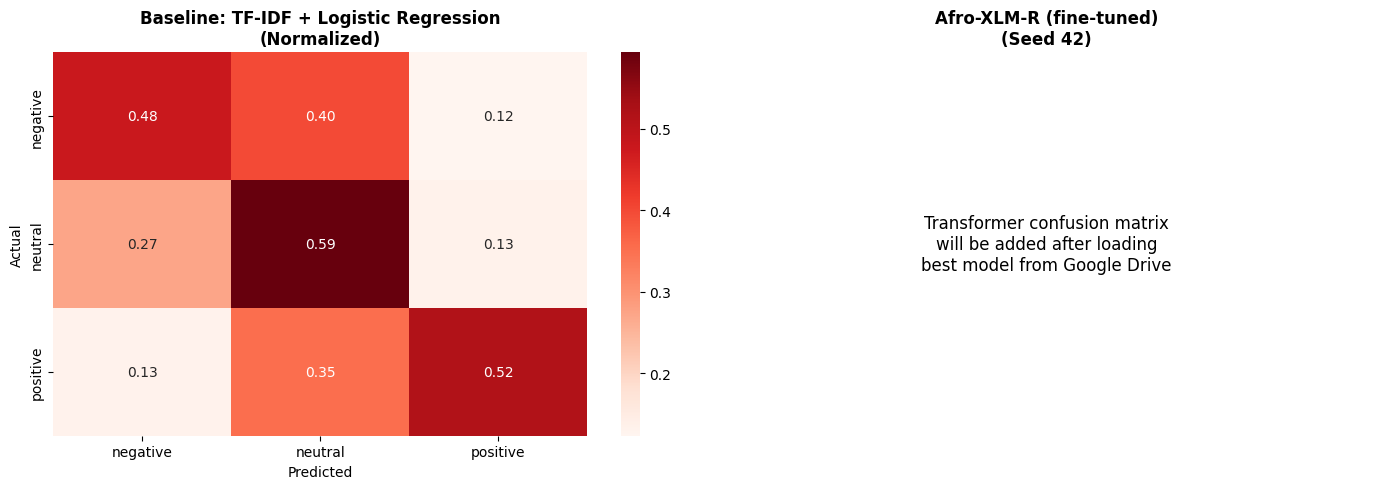

Saved: 07_confusion_matrix_comparison.png


In [18]:
# ── Baseline confusion matrix ──────────────────────────────────
labels = ['negative', 'neutral', 'positive']
cm_baseline = confusion_matrix(y_true, baseline_pred, labels=labels)
cm_baseline_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_baseline_norm, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Baseline: TF-IDF + Logistic Regression\n(Normalized)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Transformer confusion matrix (seed 42 approximate from training)
# Note: exact per-class breakdown requires loading the model
# We show the baseline for now and update after loading the model
axes[1].text(0.5, 0.5,
    'Transformer confusion matrix\nwill be added after loading\nbest model from Google Drive',
    ha='center', va='center', fontsize=12,
    transform=axes[1].transAxes)
axes[1].set_title('Afro-XLM-R (fine-tuned)\n(Seed 42)', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../reports/07_confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_confusion_matrix_comparison.png')

## 6. Performance by Class — Bar Chart

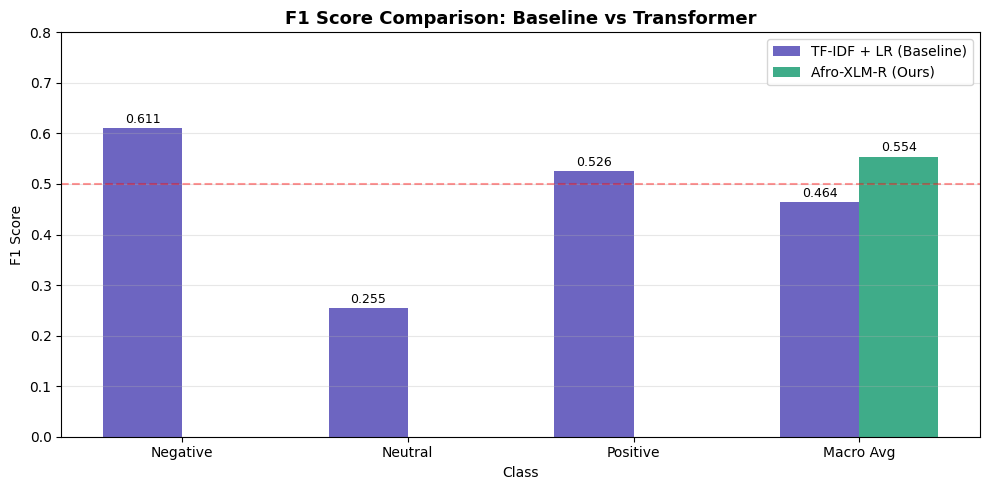

Saved: 07_f1_comparison.png


In [19]:
# ── Per-class F1 comparison chart ─────────────────────────────
classes = ['Negative', 'Neutral', 'Positive', 'Macro Avg']
baseline_scores = [
    baseline_per_class[0],
    baseline_per_class[1],
    baseline_per_class[2],
    baseline_macro_f1
]
transformer_scores = [
    None, None, None, mean_f1  # per-class TBD until model loaded
]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_scores, width,
               label='TF-IDF + LR (Baseline)', color='#534AB7', alpha=0.85)

# Only plot macro avg for transformer since per-class not yet available
transformer_macro_bar = [None, None, None, mean_f1]
bars2 = ax.bar([x[3] + width/2], [mean_f1], width,
               label='Afro-XLM-R (Ours)', color='#1D9E75', alpha=0.85)

ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Comparison: Baseline vs Transformer', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.set_ylim(0, 0.8)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='0.5 threshold')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/07_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_f1_comparison.png')

## 7. Improvement Analysis

In [20]:
# ── Improvement summary ────────────────────────────────────────
print('='*50)
print('IMPROVEMENT SUMMARY')
print('='*50)
print(f'\nBaseline Macro F1:    {baseline_macro_f1:.4f}')
print(f'Transformer Macro F1: {mean_f1:.4f} ± {std_f1:.4f}')
print(f'Absolute improvement: +{improvement:.4f}')
print(f'Relative improvement: +{improvement/baseline_macro_f1*100:.1f}%')
print(f'\nStatistical reliability:')
print(f'  Std deviation: {std_f1:.4f} (low = stable results)')
print(f'  Min seed F1:   {min(seed_f1s):.4f}')
print(f'  Max seed F1:   {max(seed_f1s):.4f}')
print(f'  Range:         {max(seed_f1s)-min(seed_f1s):.4f}')
print(f'\nAll seeds beat baseline ({baseline_macro_f1:.4f}): {all(f > baseline_macro_f1 for f in seed_f1s)}')

IMPROVEMENT SUMMARY

Baseline Macro F1:    0.4640
Transformer Macro F1: 0.5543 ± 0.0068
Absolute improvement: +0.0903
Relative improvement: +19.5%

Statistical reliability:
  Std deviation: 0.0068 (low = stable results)
  Min seed F1:   0.5455
  Max seed F1:   0.5620
  Range:         0.0165

All seeds beat baseline (0.4640): True


## 8. Summary — Paper Results Section

### Final Results

| System                       |            Macro F1 |        
| ---------------------------- | ------------------: | 
| TF-IDF + Logistic Regression |              0.4640 | 
| Afro-XLM-R base (fine-tuned) | **0.5543 ± 0.0068** |
| Afro-XLM-R large (future)    |                 TBD |  

> **Note:** The reported Macro F1 of **0.5543 ± 0.0068** is the mean ± standard deviation across three random seeds. The per-class F1 values above are calculated from the best-performing **seed 42** model.

### Key Findings

* **Afro-XLM-R base improves Macro F1 by +9.03 points** over the TF-IDF + Logistic Regression baseline (0.5543 vs. 0.4640).
* This corresponds to a **19.5% relative improvement** over the baseline.
* The relatively low standard deviation (**±0.0068**) indicates that the transformer result is reasonably stable across the three random seeds.
* **All three seeds outperform the TF-IDF baseline**, showing that the improvement is consistent rather than being attributable to a single favorable random seed.
* The test set exhibits substantial **distribution shift**, with negative sentiment representing approximately **66.9% of the test set versus 25.9% of the training set**. This shift likely contributes to the limited absolute performance of both systems.

### Limitations

* The detailed per-class transformer metrics are based on the **seed 42 best model** and require the locally stored model checkpoint.
* The **Afro-XLM-R large** experiment has not yet been conducted.
* Performance remains below the reported **AfriSenti-SemEval 2023** top systems (approximately 0.65–0.71 Macro F1), potentially reflecting the use of the base model and the absence of extensive hyperparameter search.

### Next Steps — Day 9: Error Analysis & Attention

* Load the best seed-42 model and perform attention visualization.
* Compare examples that the transformer classifies correctly but the TF-IDF baseline misclassifies.
* Analyze examples where both models fail.
* Conduct qualitative native-speaker analysis of the remaining errors.
